# Headline

## Table of Contents

Introduction

Loading and Examining the Data

    - Dataset Overview

Exploratory Data Analysis

    - Data Quality and Outlier Analysis
    
    - Distribution of Numerical Features
    
    - Correlation Analysis
    
Data Preprocessing and Feature Engineering

Feature Selection

## Introduction

## Loading and Examining the Data

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# Import required libraries
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC, Precision, Recall
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, auc,
    f1_score, confusion_matrix, classification_report
)

# Jupyter magic
%matplotlib inline

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Set visual style
sns.set_style("dark")
sns.set_palette("husl")
plt.style.use('seaborn-v0_8')
plt.rcParams["axes.facecolor"] = "#FDFFE2"
plt.rcParams["figure.facecolor"] = "#FDFFE2"
plt.rcParams["axes.edgecolor"] = "#FDFFE2"
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelpad"] = 12

# Load dataset
ipo_df = pd.read_csv("Indian_IPO_Market_Data.csv")

# 1. Display the first five and last five rows
print("===== First 5 Rows =====")
display(ipo_df.head())

print("\n===== Last 5 Rows =====")
display(ipo_df.tail())

# 2. Number of observations (rows) and variables (columns)
print("\n===== Shape of the Dataset =====")
print(f"Observations: {ipo_df.shape[0]}")
print(f"Variables: {ipo_df.shape[1]}")

# 3. Variable types (info)
print("\n===== Data Types & Non-Null Counts =====")
ipo_df.info()

# 4. Key statistics (describe, transposed)
print("\n===== Descriptive Statistics =====")
display(ipo_df.describe(include='all').T)

2025-09-26 23:48:09.092763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-26 23:48:09.116711: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-26 23:48:09.123944: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


===== First 5 Rows =====


,Date,IPOName,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
0,03/02/10,Infinite Comp,189.800,48.440,106.020,11.080,43.220,165,11.820
1,08/02/10,Jubilant Food,328.700,59.390,51.950,3.790,31.110,145,-84.210
2,15/02/10,Syncom Health,56.250,0.990,16.600,6.250,5.170,75,17.130
3,15/02/10,Vascon Engineer,199.800,1.120,3.650,0.620,1.220,165,-11.280
4,19/02/10,Thangamayil,0.000,0.520,1.520,2.260,1.120,75,-5.200



===== Last 5 Rows =====


,Date,IPOName,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
314,26/08/22,Syrma SGS,840.130,42.420,7.130,2.840,15.590,220,42.300
315,06/09/22,Dreamfolks Serv,562.100,27.480,14.180,24.190,23.250,326,41.920
316,15/09/22,TMB,792.000,0.510,1.770,3.440,1.390,525,-3.150
317,26/09/22,Harsha Engineer,755.000,113.820,40.360,12.440,47.190,330,47.240
318,17/10/22,Electronics Mar,500.000,58.810,15.390,8.270,24.230,59,43.140



===== Shape of the Dataset =====
Observations: 319
Variables: 9

===== Data Types & Non-Null Counts =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   319 non-null    object 
 1   IPOName                319 non-null    object 
 2   Issue_Size             319 non-null    float64
 3   Subscription_QIB       319 non-null    float64
 4   Subscription_HNI       319 non-null    float64
 5   Subscription_RII       319 non-null    float64
 6   Subscription_Total     319 non-null    float64
 7   Issue_Price            319 non-null    int64  
 8   Listing_Gains_Percent  319 non-null    float64
dtypes: float64(6), int64(1), object(2)
memory usage: 22.6+ KB

===== Descriptive Statistics =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,319,287,16/08/21,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IPOName,319,319,Infinite Comp,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issue_Size,319.000,NaN,NaN,NaN,"1,192.860","2,384.644",0.000,169.005,496.250,"1,100.000","21,000.000"
Subscription_QIB,319.000,NaN,NaN,NaN,25.684,40.717,0.000,1.150,4.940,34.635,215.450
Subscription_HNI,319.000,NaN,NaN,NaN,70.091,142.454,0.000,1.255,5.070,62.095,958.070
Subscription_RII,319.000,NaN,NaN,NaN,8.562,14.509,0.000,1.275,3.420,8.605,119.440
Subscription_Total,319.000,NaN,NaN,NaN,27.447,48.772,0.000,1.645,4.930,33.395,326.490
Issue_Price,319.000,NaN,NaN,NaN,375.129,353.898,0.000,119.000,250.000,536.000,"2,150.000"
Listing_Gains_Percent,319.000,NaN,NaN,NaN,4.743,47.651,-97.150,-11.555,1.810,25.310,270.400


## Dataset Overview
---
The dataset consists of information on **319 IPOs** in the Indian market, covering issue sizes, subscription details across different investor categories, issue prices, and the corresponding listing gains. It contains **9 variables** in total, with 7 numerical features and 2 categorical features.

### Sample Records
The first five and last five rows of the dataset provide a snapshot of the data:

- **First 5 Rows** include IPOs such as *Infinite Comp*, *Jubilant Food*, *Syncom Health*, *Vascon Engineer*, and *Thangamayil* from 2010.
- **Last 5 Rows** include more recent IPOs like *Syrma SGS*, *Dreamfolks Serv*, *TMB*, *Harsha Engineer*, and *Electronics Mar* from 2022.

This indicates that the dataset spans more than a decade of IPO activity.

### Dataset Shape
- **Observations (rows):** 319  
- **Variables (columns):** 9  

### Variable Types
- **Categorical Variables:** `Date`, `IPOName`  
- **Numerical Variables:** `Issue_Size`, `Subscription_QIB`, `Subscription_HNI`, `Subscription_RII`, `Subscription_Total`, `Issue_Price`, `Listing_Gains_Percent`

### Descriptive Statistics
Key insights from the numerical features:
- **Issue Size:** Ranges from *0* to *21,000 crores*, with a mean around *1,193 crores*. The large standard deviation indicates high variability between IPO sizes.
- **Subscription Levels:**
  - QIB subscriptions average *25.7x* with a maximum of *215x*.
  - HNI subscriptions show the highest variability, averaging *70x* but reaching as high as *958x*.
  - RII subscriptions average *8.6x* with a maximum of *119x*.
  - Total subscriptions average *27.4x*, but some IPOs were subscribed over *300x*.
- **Issue Price:** Ranges from *₹0* (possibly missing or erroneous entries) to *₹2150*, with a mean around *₹375*.
- **Listing Gains (%):** The average listing gain is around *4.7%*. However, the distribution is highly dispersed:
  - Minimum: *-97.15%* (loss on listing)  
  - Median: *1.81%*  
  - Maximum: *270.4%*  

### Observations
- The dataset is complete with no missing values at this stage.  
- Categorical variables (`Date` and `IPOName`) are identifiers and may not add predictive power directly but can help in temporal or group-wise analysis.  
- Numerical features show strong variability, particularly in subscription levels and issue sizes, which are likely important predictors for listing gains.  


## Exploratory Data Analysis

In [2]:
# Duplicate values
duplicates = ipo_df.duplicated().sum()
print("===== Duplicate Values =====")
print(f"Number of duplicate rows: {duplicates}")

# Missing values
missing_percent = ipo_df.isnull().mean() * 100
print("\n===== Missing Values (in %) =====")
print(missing_percent)

# Outlier Detection (IQR method)
numeric_cols = ipo_df.select_dtypes(include=['float64','int64']).columns

outliers_summary = {}
for col in numeric_cols:
    Q1 = ipo_df[col].quantile(0.25)
    Q3 = ipo_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ipo_df[(ipo_df[col] < lower_bound) | (ipo_df[col] > upper_bound)][col].count()
    outliers_summary[col] = outliers

outliers_df = pd.DataFrame.from_dict(outliers_summary, orient='index', columns=['Outlier_Count'])
print("\n===== Outliers per Numerical Column =====")
display(outliers_df)

===== Duplicate Values =====
Number of duplicate rows: 0

===== Missing Values (in %) =====
Date                    0.000
IPOName                 0.000
Issue_Size              0.000
Subscription_QIB        0.000
Subscription_HNI        0.000
Subscription_RII        0.000
Subscription_Total      0.000
Issue_Price             0.000
Listing_Gains_Percent   0.000
dtype: float64

===== Outliers per Numerical Column =====


,Outlier_Count
Issue_Size,34
Subscription_QIB,35
Subscription_HNI,48
Subscription_RII,33
Subscription_Total,31
Issue_Price,12
Listing_Gains_Percent,46


## Data Quality and Outlier Analysis
---
### Duplicate Values
- The dataset contains **0 duplicate rows**, confirming that all records are unique.

### Missing Values
- There are **no missing values** across any of the 9 variables.  
- This ensures that the dataset is complete and does not require imputation for missing data.

### Outlier Detection
- Outliers were identified using the **Interquartile Range (IQR) method** for each numerical column:
- Outliers are present in **all numerical features**, with the highest counts in `Subscription_HNI` (48) and `Listing_Gains_Percent` (46).  
- These outliers likely represent extreme IPO events, such as heavily oversubscribed offerings or unusually high listing gains.  
- Since IPO data is inherently volatile, some of these outliers may carry **meaningful information** rather than being errors.


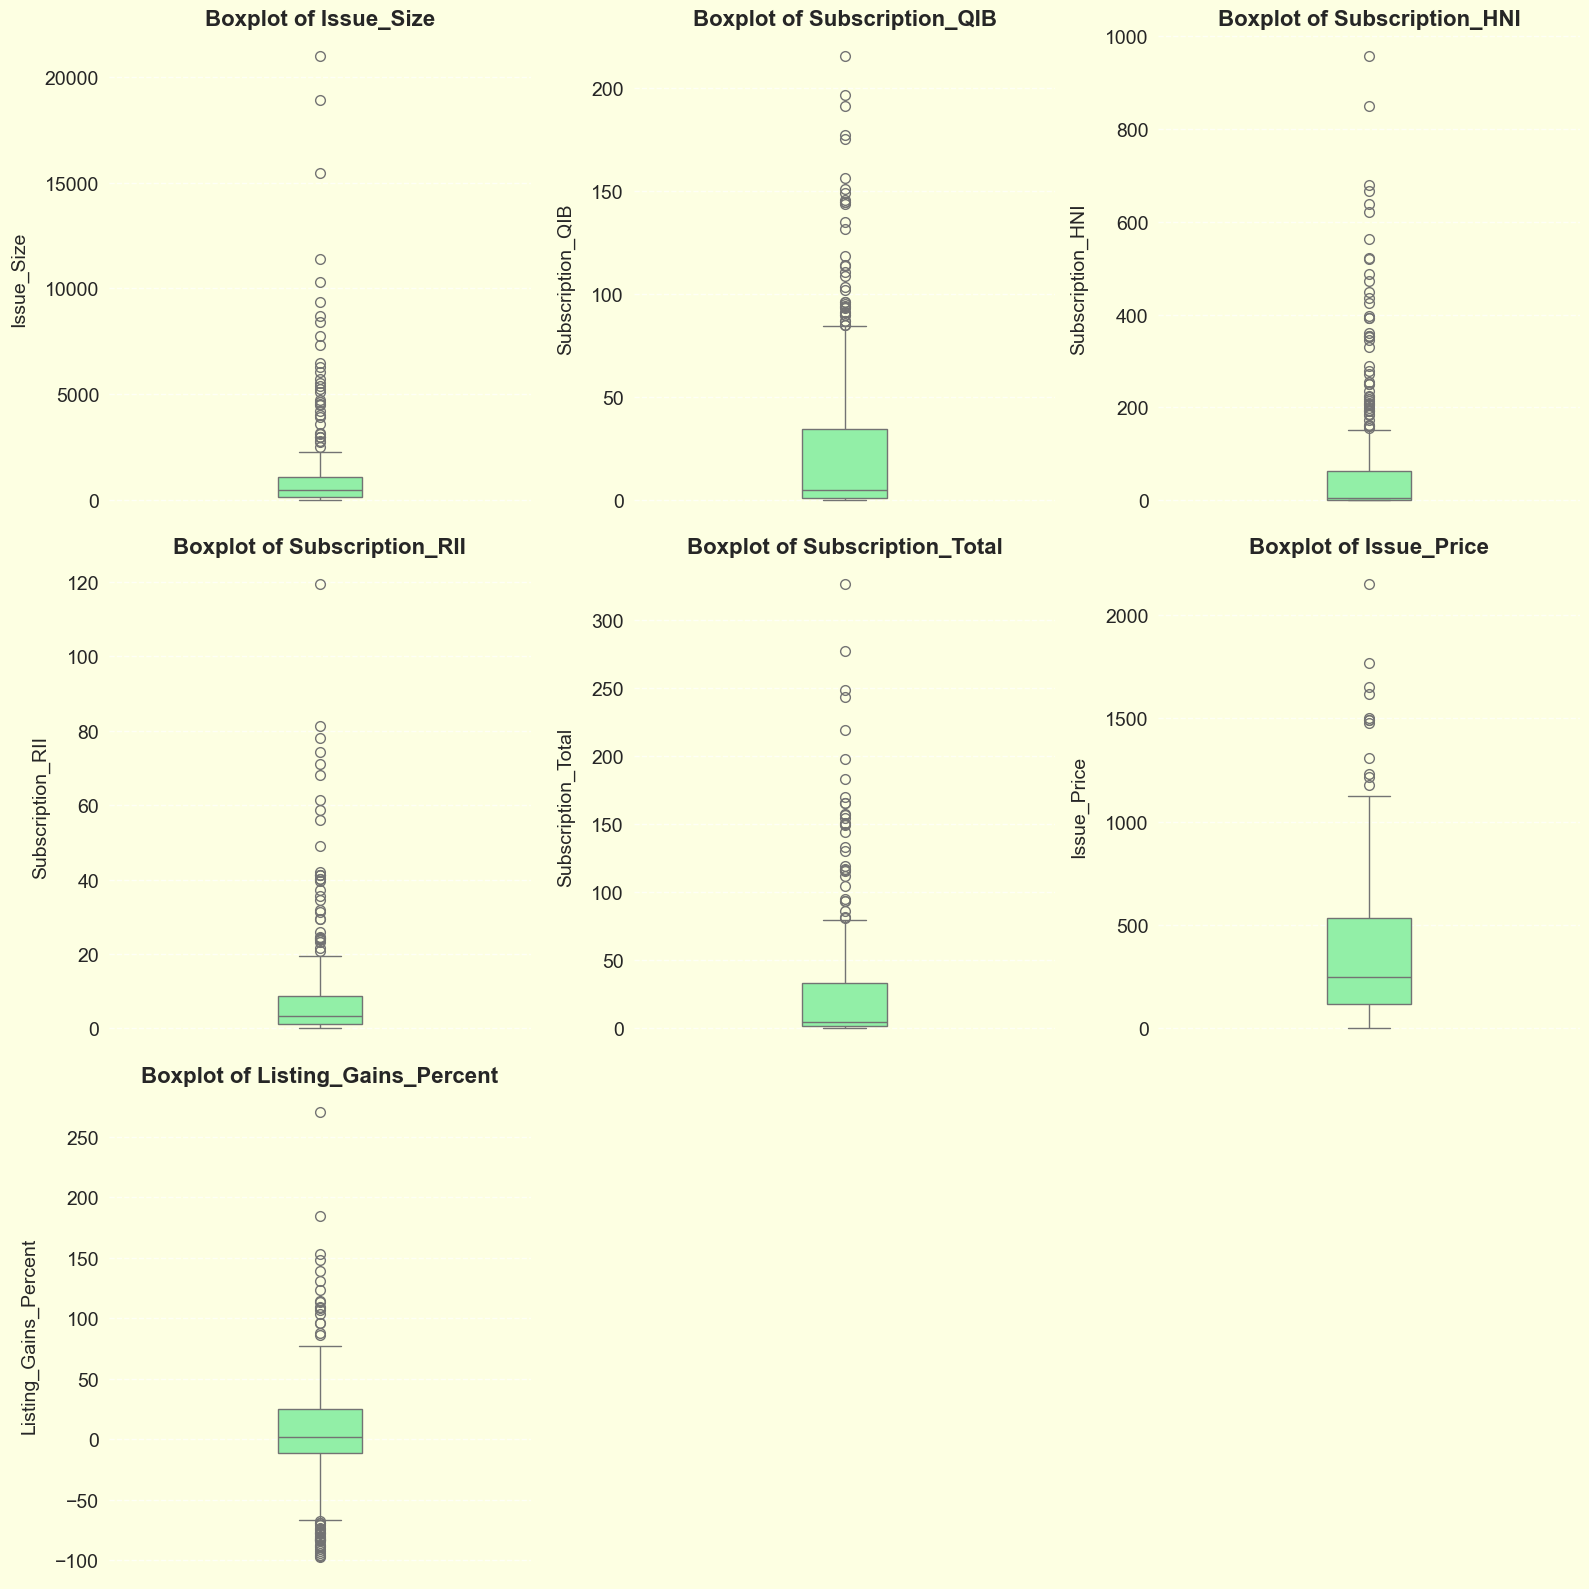

In [3]:
# Boxplots for numerical columns
plt.figure(figsize=(16, 16))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=ipo_df[col], color="#82FF9E", width=.2)
    plt.title(f"Boxplot of {col}")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Distribution of Numerical Features
---
Boxplots were generated for all 7 numerical variables in the dataset to assess the spread of the data and identify potential outliers.

### Key Insights
- **Issue_Size:** Most IPOs have relatively small to mid-sized issues, but a few reach extremely large values (above ₹15,000 crores). The long tail highlights the presence of very large offerings compared to the majority.  
- **Subscription_QIB, Subscription_HNI, Subscription_RII, Subscription_Total:**  
  - All four subscription-related variables exhibit **strong right skewness** with numerous outliers.  
  - A small number of IPOs were subscribed at exceptionally high levels (e.g., QIB over 200x, HNI close to 1,000x).  
  - These outliers reflect blockbuster IPOs that generated extraordinary investor demand.  
- **Issue_Price:** The majority of IPOs are priced below ₹600, though some extend beyond ₹2,000. The presence of outliers suggests premium-priced IPOs exist in the dataset.  
- **Listing_Gains_Percent:** The distribution is highly variable. While most IPOs show modest gains or losses around the median (~2%), several IPOs experienced **very high positive gains (above 200%)** or significant losses (close to -100%).  

### Observations
- The **heavy right skew** in issue size and subscription levels is expected in IPO data, as a handful of offerings attract disproportionate investor interest.  
- Outliers in `Listing_Gains_Percent` are particularly important, as they represent extreme outcomes for investors — both spectacular gains and steep losses.  
- These patterns suggest that normalization or transformation of some variables may be beneficial before modeling, but the extreme cases may also provide **critical signals** for predicting listing gains.  


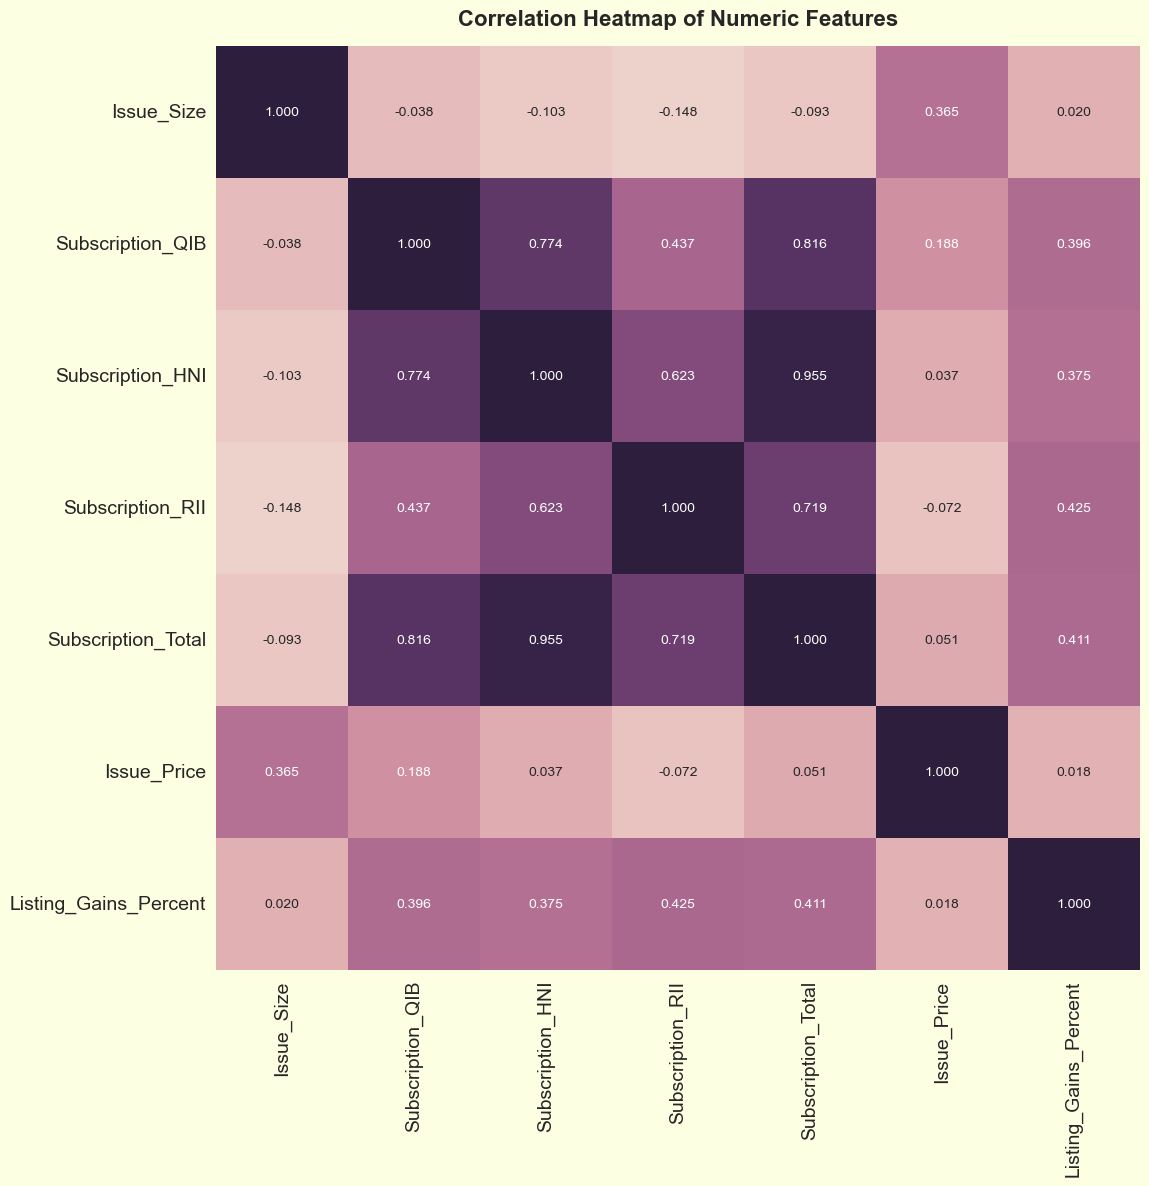

In [4]:
# Correlation Heatmap
corr_matrix = ipo_df[numeric_cols].corr()

plt.figure(figsize=(12, 12))
sns.heatmap(
    corr_matrix, 
    annot=True, fmt=".3f", cmap=sns.cubehelix_palette(as_cmap=True), 
    cbar=False, square=True, linewidths=0
)
plt.title("Correlation Heatmap of Numeric Features", pad=15)
plt.show()

## Correlation Analysis
---
The correlation heatmap highlights the relationships between the numerical variables in the dataset.

### Key Insights
- **Subscription Variables:**
  - `Subscription_Total` is highly correlated with both `Subscription_HNI` (**0.955**) and `Subscription_QIB` (**0.816**).  
  - Strong correlations also exist between `Subscription_HNI` and `Subscription_QIB` (**0.774**) and between `Subscription_HNI` and `Subscription_RII` (**0.623**).  
  - These results confirm that total subscription demand is largely driven by institutional (QIB) and HNI investor participation, though retail investors (RII) also contribute meaningfully.  

- **Listing Gains (%):**
  - Shows **moderate positive correlations** with all subscription categories:
    - `Subscription_RII` (**0.425**)  
    - `Subscription_Total` (**0.411**)  
    - `Subscription_QIB` (**0.396**)  
    - `Subscription_HNI` (**0.375**)  
  - This indicates that **higher subscription demand across investor categories is generally associated with higher listing gains**.  
  - However, no single feature exhibits an extremely strong correlation, suggesting that listing gains are influenced by multiple interacting factors beyond subscription levels alone.  

- **Issue Size:**
  - Weakly correlated with other variables, including `Listing_Gains_Percent` (**0.020**). Larger issue sizes do not necessarily translate into higher or lower listing gains.  

- **Issue Price:**
  - Positively correlated with `Issue_Size` (**0.365**) but shows virtually no relationship with listing gains (**0.018**).  
  - This suggests that while higher-priced IPOs tend to be larger in size, **issue price itself is not a strong determinant of first-day performance**.  

### Observations
- Subscription data (QIB, HNI, RII, and Total) are key predictive indicators for listing gains.  
- Issue size and issue price are less influential in determining listing outcomes.  
- The moderate correlations suggest that a **multivariate approach** is well-suited to capture the interplay between features and predict listing gains.  


## Data Preprocessing and Feature Engineering

In [5]:
# Remove whitespace from column names
ipo_df.columns = ipo_df.columns.str.strip()

# Add binary target
ipo_df["Profit"] = (ipo_df["Listing_Gains_Percent"] > 0).astype(int)

# Parse date and extract year
ipo_df["Date_dt"] = pd.to_datetime(ipo_df["Date"], format="%d/%m/%y", dayfirst=True, errors="coerce")
ipo_df["Year"] = ipo_df["Date_dt"].dt.year

# Log-transform skewed non-negative features
log_cols = [
    "Issue_Size",
    "Subscription_QIB",
    "Subscription_HNI",
    "Subscription_RII",
    "Subscription_Total",
    "Issue_Price",
]
for c in log_cols:
    ipo_df[f"{c}_log"] = np.log1p(ipo_df[c].clip(lower=0))

# Drop non-predictive identifiers
ipo_df_final = ipo_df.drop(columns=["Date", "IPOName", "Date_dt"])

# Display the final result
ipo_df_final

,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent,Profit,Year,Issue_Size_log,Subscription_QIB_log,Subscription_HNI_log,Subscription_RII_log,Subscription_Total_log,Issue_Price_log
0,189.800,48.440,106.020,11.080,43.220,165,11.820,1,2010,5.251,3.901,4.673,2.492,3.789,5.112
1,328.700,59.390,51.950,3.790,31.110,145,-84.210,0,2010,5.798,4.101,3.969,1.567,3.469,4.984
2,56.250,0.990,16.600,6.250,5.170,75,17.130,1,2010,4.047,0.688,2.868,1.981,1.820,4.331
3,199.800,1.120,3.650,0.620,1.220,165,-11.280,0,2010,5.302,0.751,1.537,0.482,0.798,5.112
4,0.000,0.520,1.520,2.260,1.120,75,-5.200,0,2010,0.000,0.419,0.924,1.182,0.751,4.331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,840.130,42.420,7.130,2.840,15.590,220,42.300,1,2022,6.735,3.771,2.096,1.345,2.809,5.398
315,562.100,27.480,14.180,24.190,23.250,326,41.920,1,2022,6.333,3.349,2.720,3.226,3.188,5.790
316,792.000,0.510,1.770,3.440,1.390,525,-3.150,0,2022,6.676,0.412,1.019,1.491,0.871,6.265
317,755.000,113.820,40.360,12.440,47.190,330,47.240,1,2022,6.628,4.743,3.722,2.598,3.875,5.802


## Analysing the Data Preprocessing and Feature Engineering Steps
---
### 1. Cleaning Column Names
- Leading and trailing whitespaces were removed from column names to ensure consistency when referencing variables.

### 2. Target Variable Creation
- A new binary target variable **Profit** was created:
  - **1** if **Listing_Gains_Percent > 0** (IPO closed with a profit on listing day).  
  - **0** otherwise (IPO closed at a loss or no gain).  
- This transformation reframed the problem as a **binary classification task**, which will be addressed using a deep learning model.

### 3. Date Feature Engineering
- The `Date` column was converted to datetime format.  
- From it, the **`Year`** of listing was extracted, capturing potential macroeconomic and market-cycle effects.  
- Other time-based features (month, quarter) were not included to keep the feature space simpler and avoid unnecessary noise.

### 4. Log Transformation of Skewed Features
- Several numerical features showed heavy right skewness and extreme outliers:
  - `Issue_Size`, `Subscription_QIB`, `Subscription_HNI`, `Subscription_RII`, `Subscription_Total`, `Issue_Price`
- These were **log-transformed using `log1p`** to reduce skewness, compress extreme values, and stabilize variance.  
- The transformed versions were added as new features with `_log` suffix.

### 5. Dropping Non-Predictive Identifiers
- `Date`, `IPOName`, and the intermediate `Date_dt` column were dropped, as they are identifiers and do not directly contribute to prediction after feature extraction.


## Feature Selection

In [6]:
# Build feature set (exclude leakage from Listing_Gains_Percent)
feature_cols = [f"{c}_log" for c in log_cols] + ["Year"]
target_col = "Profit"

X = ipo_df_final[feature_cols].copy()
y = ipo_df_final[target_col].copy()

# Scale numerical features
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=feature_cols,
    index=X.index
)

# Display the Selected Features
X_scaled

,Issue_Size_log,Subscription_QIB_log,Subscription_HNI_log,Subscription_RII_log,Subscription_Total_log,Issue_Price_log,Year
0,-0.535,1.128,1.124,0.822,1.061,-0.321,-1.370
1,-0.176,1.256,0.766,-0.067,0.843,-0.439,-1.370
2,-1.325,-0.930,0.205,0.331,-0.280,-1.037,-1.370
3,-0.501,-0.889,-0.473,-1.109,-0.976,-0.321,-1.370
4,-3.983,-1.102,-0.785,-0.437,-1.008,-1.037,-1.370
...,...,...,...,...,...,...,...
314,0.439,1.045,-0.188,-0.279,0.393,-0.059,1.399
315,0.176,0.775,0.130,1.529,0.652,0.300,1.399
316,0.400,-1.107,-0.737,-0.140,-0.926,0.736,1.399
317,0.369,1.668,0.640,0.925,1.119,0.311,1.399


## Feature Set and Scaling
---
- The final feature set included:
  - Log-transformed subscription and size-related features.  
  - `Year` as a numeric time-based feature.  
- The target variable was **`Profit`**.  
- Features were standardized using **`StandardScaler`** to have mean = 0 and standard deviation = 1, ensuring comparable scales across all inputs.  
- Scaling benefits deep learning models by improving gradient-based optimization and convergence stability.


## Bulding a Deep Learning Model

In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,     # 20% for testing
    random_state=42,   # reproducibility
    stratify=y         # preserves class balance in both sets
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set:  {X_test.shape[0]} rows")

# Check class balance
train_balance = y_train.value_counts(normalize=True).rename("proportion_train")
test_balance = y_test.value_counts(normalize=True).rename("proportion_test")

balance_df = pd.concat([train_balance, test_balance], axis=1)
print("\nClass balance (0 = No Profit, 1 = Profit):")
display(balance_df)

Train set: 255 rows
Test set:  64 rows

Class balance (0 = No Profit, 1 = Profit):


,proportion_train,proportion_test
Profit,,
1,0.545,0.547
0,0.455,0.453


In [8]:
# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

def to_f32(a):
    return np.asarray(getattr(a, "values", a), dtype=np.float32)

# Assumes you already have X_train, y_train, X_test, y_test from earlier
Xtr_np = to_f32(X_train)
ytr_np = to_f32(y_train).ravel()
Xte_np = to_f32(X_test)
yte_np = to_f32(y_test).ravel()

# Safety checks
for name, arr in [("X_train", Xtr_np), ("y_train", ytr_np), ("X_test", Xte_np), ("y_test", yte_np)]:
    assert np.isfinite(arr).all(), f"{name} contains non-finite values"

# Stratified train/val from the training fold
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
(train_idx, val_idx), = sss.split(Xtr_np, ytr_np)
X_tr, X_val = Xtr_np[train_idx], Xtr_np[val_idx]
y_tr, y_val = ytr_np[train_idx], ytr_np[val_idx]

print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Test: {Xte_np.shape}")
print(f"y_tr share of class 1: {y_tr.mean():.3f} | y_val: {y_val.mean():.3f} | y_test: {yte_np.mean():.3f}")

inp = Input(shape=(X_tr.shape[1],), name="inputs")
x = layers.Dense(16, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4),
                 name="dense_16")(inp)
x = layers.BatchNormalization(name="bn_1")(x)
x = layers.Dropout(0.2, name="dropout_1")(x)
x = layers.Dense(8, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4),
                 name="dense_8")(x)
x = layers.BatchNormalization(name="bn_2")(x)
x = layers.Dropout(0.2, name="dropout_2")(x)
out = layers.Dense(1, activation="sigmoid", name="output")(x)

model = Model(inputs=inp, outputs=out, name="ipo_functional_nn")
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="auc"), Precision(name="precision"), Recall(name="recall")]
)

es = EarlyStopping(monitor="val_auc", mode="max", patience=20, restore_best_weights=True, verbose=1)
rlrp = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-5, verbose=1)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=500,
    batch_size=16,
    callbacks=[es, rlrp],
    verbose=1
)

# Validation curves
val_proba = model.predict(X_val, verbose=0).ravel()
test_proba = model.predict(Xte_np, verbose=0).ravel()

# ROC / PR metrics
roc_auc_val  = roc_auc_score(y_val, val_proba)
prec, rec, thr = precision_recall_curve(y_val, val_proba)
pr_auc_val = auc(rec, prec)

print(f"Validation ROC-AUC: {roc_auc_val:.3f} | PR-AUC: {pr_auc_val:.3f}")

# choose best threshold on val by F1
candidate_thr = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_val, (val_proba >= t).astype(int)) for t in candidate_thr]
best_idx = int(np.argmax(f1s))
best_thr = float(candidate_thr[best_idx])
print(f"Best F1 on val: {f1s[best_idx]:.3f} at threshold = {best_thr:.2f}")

# apply to test
test_pred = (test_proba >= best_thr).astype(int)
print("\nTest set metrics @ best val F1 threshold:")
print("ROC-AUC:", roc_auc_score(y_test, test_proba).round(3))
print(classification_report(y_test, test_pred, digits=3))

# confusion matrix
cm = confusion_matrix(y_test, test_pred)
print("Confusion Matrix:\n", cm)

Train: (204, 7), Val: (51, 7), Test: (64, 7)
y_tr share of class 1: 0.544 | y_val: 0.549 | y_test: 0.547
Epoch 1/500


2025-09-26 23:48:12.945367: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.4118 - auc: 0.4075 - loss: 1.1220 - precision: 0.4609 - recall: 0.4775 - val_accuracy: 0.4314 - val_auc: 0.4208 - val_loss: 0.8645 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4020 - auc: 0.3597 - loss: 1.1442 - precision: 0.4513 - recall: 0.4595 - val_accuracy: 0.4314 - val_auc: 0.4713 - val_loss: 0.8159 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4804 - auc: 0.4824 - loss: 0.9112 - precision: 0.5203 - recall: 0.5766 - val_accuracy: 0.4902 - val_auc: 0.5241 - val_loss: 0.7746 - val_precision: 0.7500 - val_recall: 0.1071 - learning_rate: 0.0010
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5294 - auc: 0.5622 - loss: 0.8404 - precision: 0.5641 - recall: 0.5946 - val_accuracy: 0.4902 - val_auc: 0.5497 - val_loss: 0.7471 -

## Model Evaluation
---
### Setup & Data
- **Model:** Small Keras MLP (7 inputs → [16] → [8] → 1, BN + Dropout, L2); ~**369** params.
- **Splits:** Train **204**, Val **51**, Test **64** (stratified).
- **Class share (Profit=1):** Train **0.544**, Val **0.549**, Test **0.547** — roughly balanced.
- **Threshold selection:** Picked on validation by **max F1** → **t = 0.40** (Val F1 ≈ **0.789**).

### Headline Metrics
- **Validation:** ROC-AUC ≈ **0.727**, PR-AUC ≈ **0.732**.
- **Test (at t = 0.40):**
  - **ROC-AUC:** **0.72** (ranking quality is decent).
  - **Accuracy:** **0.625** (not the right KPI when threshold is misaligned).
  - **Per-class (sklearn report):**
    - Class **0** (No Profit): precision **0.857**, recall **0.207**, F1 **0.333** (support 29)
    - Class **1** (Profit): precision **0.596**, recall **0.971**, F1 **0.739** (support 35)
  - **Balanced accuracy:** ~**0.589**.
  - **Confusion matrix:**

    |              | Pred 0 | Pred 1 |
    |--------------|:------:|:------:|
    | **Actual 0** |   6    |  23    |
    | **Actual 1** |   1    |  34    |

### What’s good
- **Ranking ability is solid:** AUC around **0.72** on both val and test shows the model **orders IPOs reasonably well** by profitability likelihood.
- **High sensitivity to “Profit”:** At t=0.40, recall for class 1 is **0.971** — the model almost never misses a profitable IPO.

### What’s not ideal
- **Too many false positives:** Specificity is low (only **6/29** no-profit IPOs correctly rejected). The F1-optimized threshold (**0.40**) **over-favors recall**, leading the model to predict “Profit” for most cases.
- **Accuracy is misleading:** With that threshold, accuracy drops to **0.625** despite decent AUC; this is a **thresholding, not modeling, problem**.
- **Small sample sizes:** With only **64** test cases, metric variance is non-trivial; tiny shifts in threshold can swing results.


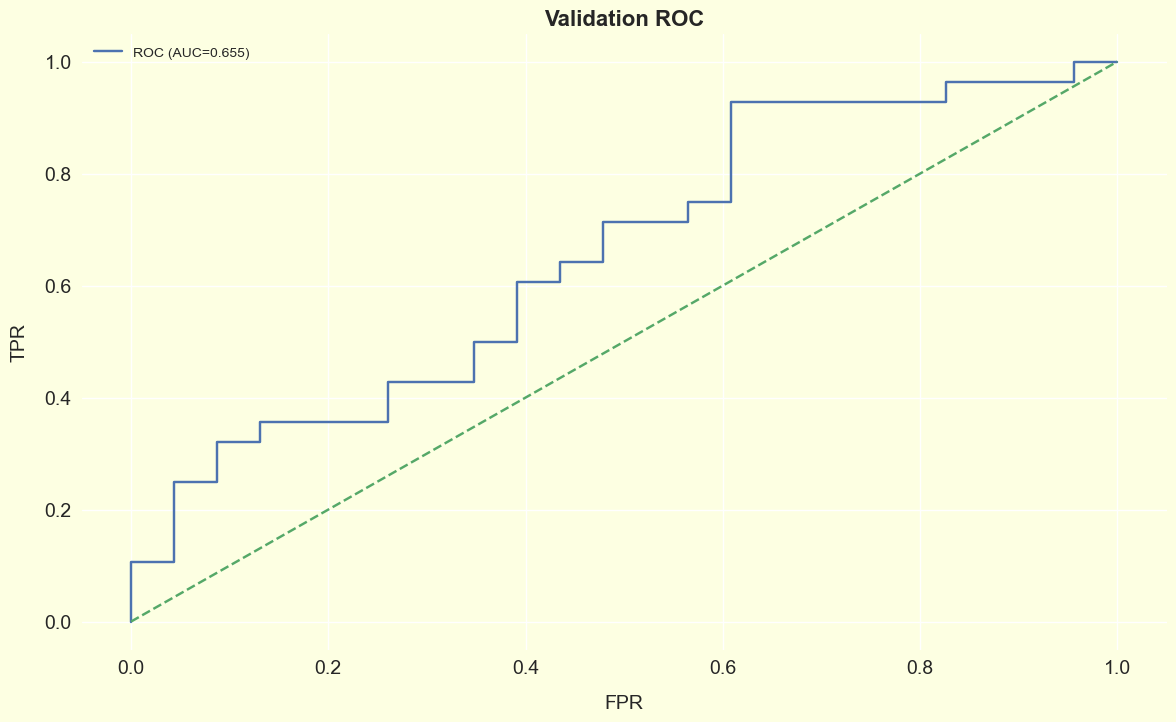

In [9]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, val_proba)
plt.figure(figsize=(14,8))
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc_val:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Validation ROC")
plt.legend()
plt.show()

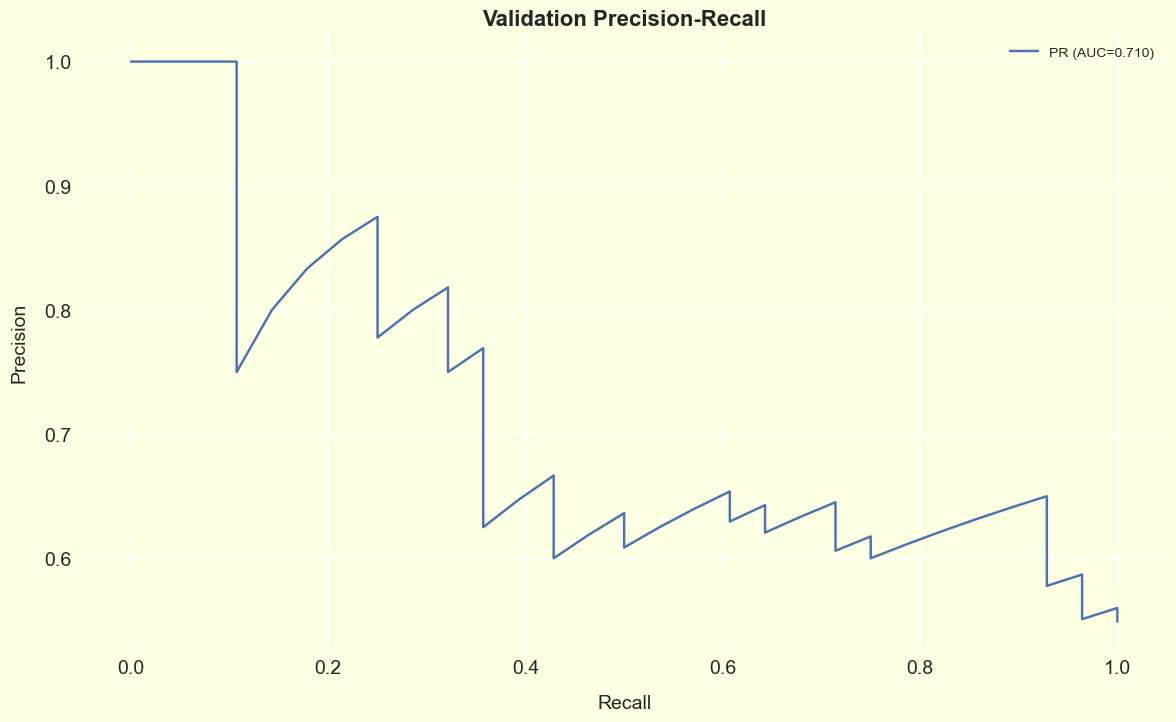

In [10]:
# Plot Precision–Recall Curve 
plt.figure(figsize=(14,8))
plt.plot(rec, prec, label=f"PR (AUC={pr_auc_val:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall")
plt.legend()
plt.show()